#import and setting up notebook

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.multivariate.manova import MANOVA
from scipy.stats import ttest_1samp
from scipy.stats import zscore 


In [ ]:
#load data
df = pd.read_csv('neu502b/502b_analysis/DOSPERT_Risk_scoring.csv')

In [3]:
print(df.columns)

Index(['Participant ID', 'Item', 'RT ', 'EB', 'PR', 'Domain', 'Age'], dtype='object')


In [4]:
#clean data

df = df.dropna(subset=['RT ', 'EB', 'PR', 'Participant ID'])


In [5]:
df.columns = df.columns.str.strip()

In [17]:
#standarize within participant

df[['RT_z', 'EB_z', 'PR_z']] = (
    df.groupby('Participant ID')[['RT', 'EB', 'PR']]
      .transform(zscore)
)

In [33]:
results = []

for pid, subdf in df.groupby('Participant ID'):
    X = subdf[['EB_z', 'PR_z']]
    X = sm.add_constant(X)
    y = subdf['RT_z']

    model = sm.OLS(y, X).fit()

    results.append({
        'Participant ID': pid,
        'intercept': model.params['const'],
        'a (EB_z)': model.params['EB_z'],
        'b (PR_z)': model.params['PR_z']
    })

results_df = pd.DataFrame(results)

In [35]:
#merge with participant-level variables

participant_vars = df.drop_duplicates('Participant ID')[['Participant ID', 'Age']]

final_df = pd.merge(results_df, participant_vars, on='Participant ID')


In [36]:
final_df = final_df.rename(columns={
    'a (EB_z)': 'a',
    'b (PR_z)': 'b'
})

In [37]:

model = smf.mixedlm(
    "RT_z ~ EB_z + PR_z",
    data=df,
    groups=df["Participant ID"]
).fit()

print(model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: RT_z     
No. Observations: 84      Method:             REML     
No. Groups:       3       Scale:              0.7336   
Min. group size:  28      Log-Likelihood:     -109.0132
Max. group size:  28      Converged:          Yes      
Mean group size:  28.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.000    0.093  0.000 1.000 -0.183  0.183
EB_z          0.351    0.095  3.687 0.000  0.164  0.537
PR_z         -0.351    0.095 -3.687 0.000 -0.537 -0.164
Group Var     0.000                                    



/usr/people/snb3/miniconda3/envs/neu502b/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/people/snb3/miniconda3/envs/neu502b/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/people/snb3/miniconda3/envs/neu502b/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [6]:
df[['RT_z', 'EB_z', 'PR_z']] = df.groupby('Participant ID')[['RT','EB','PR']].transform(zscore)

In [7]:
results = []

for pid, subdf in df.groupby('Participant ID'):
    subdf = subdf[['RT_z', 'EB_z', 'PR_z']].dropna()
    if len(subdf) < 3:  # need enough trials
        continue

    X = sm.add_constant(subdf[['EB_z', 'PR_z']])
    y = subdf['RT_z']

    model = sm.OLS(y, X).fit()
    
    results.append({
        'Participant ID': pid,
        'intercept': model.params['const'],
        'a (benefit sensitivity)': model.params['EB_z'],
        'b (risk attitude)': model.params['PR_z']
    })

participant_coeffs = pd.DataFrame(results)

In [8]:
participant_coeffs.describe()

,Participant ID,intercept,a (benefit sensitivity),b (risk attitude)
count,3.0,3.000000e+00,3.000000,3.000000
mean,2.0,-9.251859e-18,0.359735,-0.334485
std,1.0,1.397000e-16,0.348577,0.260062
min,1.0,-1.387779e-16,-0.005259,-0.627319
25%,1.5,-8.326673e-17,0.195019,-0.436496
50%,2.0,-2.775558e-17,0.395296,-0.245673
75%,2.5,5.551115e-17,0.542232,-0.188068
max,3.0,1.387779e-16,0.689168,-0.130464


In [9]:
#ttest 1 s
ttest_1samp(participant_coeffs['a (benefit sensitivity)'], 0)
ttest_1samp(participant_coeffs['b (risk attitude)'], 0)

TtestResult(statistic=np.float64(-2.227723698724688), pvalue=np.float64(0.15575045702223408), df=np.int64(2))

/tmp/ipykernel_657337/1573773078.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


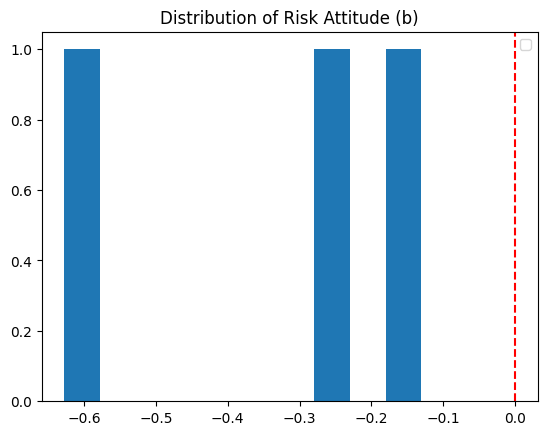

In [10]:
plt.hist(participant_coeffs['b (risk attitude)'])
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Risk Attitude (b)')
plt.legend()
plt.show()

In [11]:
#overall a and b per participant
# Z-score within participant
df[['RT_z', 'EB_z', 'PR_z']] = df.groupby('Participant ID')[['RT','EB','PR']].transform(zscore)

overall_results = []

for pid, subdf in df.groupby('Participant ID'):
    subdf = subdf[['RT_z','EB_z','PR_z']].dropna()
    if len(subdf) < 3:
        continue
    X = sm.add_constant(subdf[['EB_z','PR_z']])
    y = subdf['RT_z']
    model = sm.OLS(y,X).fit()
    overall_results.append({
        'Participant ID': pid,
        'intercept': model.params['const'],
        'a_overall': model.params['EB_z'],
        'b_overall': model.params['PR_z']
    })

overall_df = pd.DataFrame(overall_results)

In [12]:
#domain specific a and b per participant
domain_results = []

for pid, subdf in df.groupby('Participant ID'):
    for domain, ddf in subdf.groupby('Domain'):
        ddf = ddf[['RT_z','EB_z','PR_z']].dropna()
        if len(ddf) < 3:
            continue
        X = sm.add_constant(ddf[['EB_z','PR_z']])
        y = ddf['RT_z']
        model = sm.OLS(y,X).fit()
        domain_results.append({
            'Participant ID': pid,
            'Domain': domain,
            'intercept': model.params['const'],
            'a_domain': model.params['EB_z'],
            'b_domain': model.params['PR_z']
        })

domain_df = pd.DataFrame(domain_results)

In [13]:
merged_df = domain_df.merge(overall_df, on='Participant ID')